In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")


import scipy.stats as stats
from tqdm import tqdm
from network_time_varying import TimeVaryingFeedForward

In [3]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'

In [4]:
net = TimeVaryingFeedForward(time_varying=True, pre_run=False)
net.run()

Inh scale timeline: [1.  1.  1.  1.  1.  1.  1.  0.7 0.7 0.7 0.7 0.7 0.7 0.7 1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1.  1.  1. ]


100%|██████████| 840/840 [00:43<00:00, 19.51it/s]


In [5]:
net_non_varying = TimeVaryingFeedForward(time_varying=False)
net_non_varying.run()

Inh scale timeline: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


100%|██████████| 840/840 [00:43<00:00, 19.51it/s]


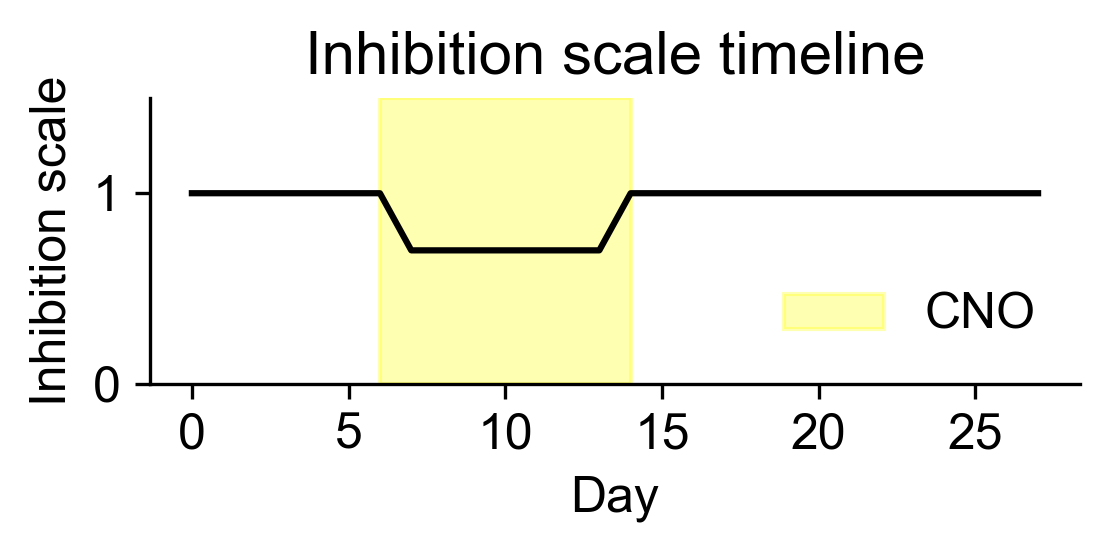

In [6]:
# Plot timeline of inhibition scale
net.plot_inh_scale_timeline()


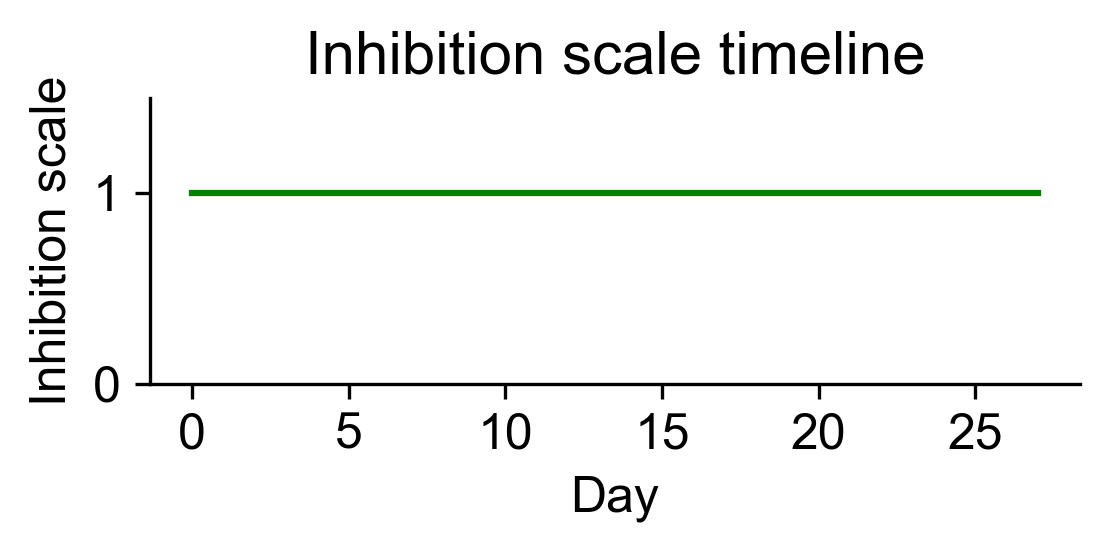

In [7]:
net_non_varying.plot_inh_scale_timeline(color='green', CNO=False)

In [8]:
drift_mag, drift_rate, convergence = net.get_metrics(net.N, net.n_days, net.theta_stim, net.POs)

drift_mag_non_varying, drift_rate_non_varying, convergence_non_varying = net_non_varying.get_metrics(net_non_varying.N, net_non_varying.n_days, net_non_varying.theta_stim, net_non_varying.POs)

<>:26: SyntaxWarning: invalid escape sequence '\;'
<>:26: SyntaxWarning: invalid escape sequence '\;'
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_28835/3849872383.py:26: SyntaxWarning: invalid escape sequence '\;'
  axs[2].set_ylabel('convergence $ \; [\degree]$')
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_28835/3849872383.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


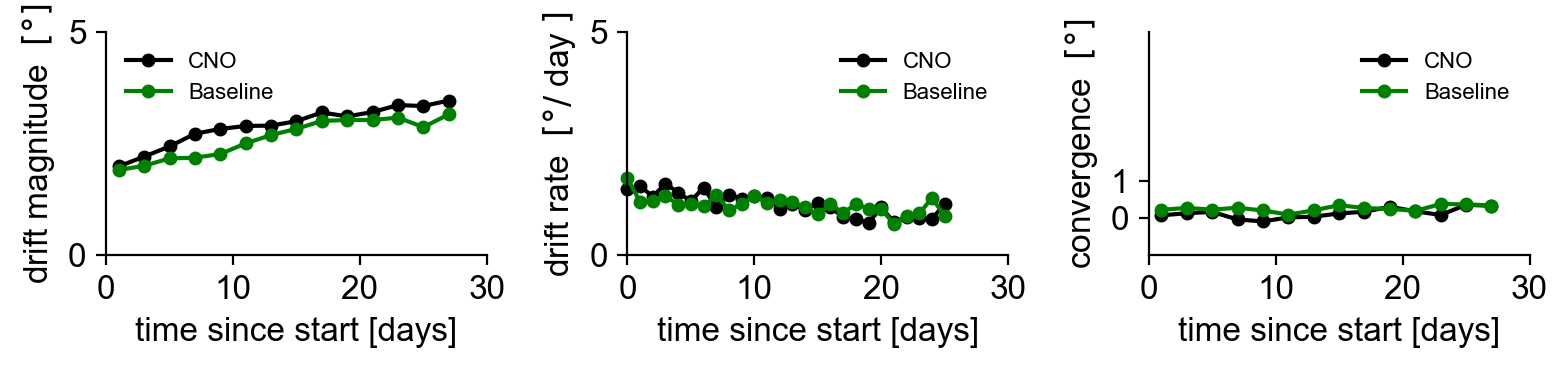

In [9]:
eo = 2


fig, axs = plt.subplots(1, 3, figsize=(8, 2), dpi=200)
axs[0].plot(np.arange(1, net.n_days)[::eo], np.median(drift_mag, axis=1)[:-1][::eo], c='black', ls='-', marker='o', ms=4, label='CNO', clip_on=False)
axs[0].plot(np.arange(1, net_non_varying.n_days)[::eo], np.median(drift_mag_non_varying, axis=1)[:-1][::eo], c='green', ls='-', marker='o', ms=4, label='Baseline', clip_on=False)
axs[0].set_ylim([0, 5]); axs[0].set_yticks([0, 5])
axs[0].set_xlabel('time since start [days]')
axs[0].set_ylabel(r'drift magnitude $ \; [\degree]$')
axs[0].set_xlim(0, 30)
axs[0].legend(frameon=False, fontsize=8)


axs[1].plot(np.mean(drift_rate, axis=1)[:-1], c='black', ls='-', marker='o', ms=4, label='CNO', clip_on=False)
axs[1].plot(np.mean(drift_rate_non_varying, axis=1)[:-1], c='green', ls='-', marker='o', ms=4, label='Baseline', clip_on=False)
axs[1].set_ylim([0, 5]); axs[1].set_yticks([0, 5])
axs[1].set_xlabel('time since start [days]')
axs[1].set_ylabel(r'drift rate $ \; [\degree / $ day $]$')
axs[1].set_xlim(0, 30)  
axs[1].legend(frameon=False, fontsize=8)

axs[2].plot(np.arange(1, net.n_days)[::eo], np.median(convergence, axis=1)[::eo], c='black', ls='-', marker='o', ms=4, label='CNO', clip_on=False)
axs[2].plot(np.arange(1, net_non_varying.n_days)[::eo], np.median(convergence_non_varying, axis=1)[::eo], c='green', ls='-', marker='o', ms=4, label='Baseline', clip_on=False)
axs[2].set_ylim([-1, 5]); axs[2].set_yticks([0, 1])
axs[2].set_xlabel('time since start [days]')
axs[2].set_ylabel('convergence $ \; [\degree]$')
axs[2].set_xlim(0, 30)
axs[2].legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.show()

### Plot individual tuning curves at specific days

In [10]:

tuning_curves_day_1 = net.estimate_tuning_curves_at_day(day=1)
tuning_curves_day_8 = net.estimate_tuning_curves_at_day(day=8)

tuning_curves_day_1_non_varying = net_non_varying.estimate_tuning_curves_at_day(day=1)
tuning_curves_day_8_non_varying = net_non_varying.estimate_tuning_curves_at_day(day=8)

Text(0.5, 1.0, 'Cell Idx: 230 - Tuning curves at Day 1 and Day 8')

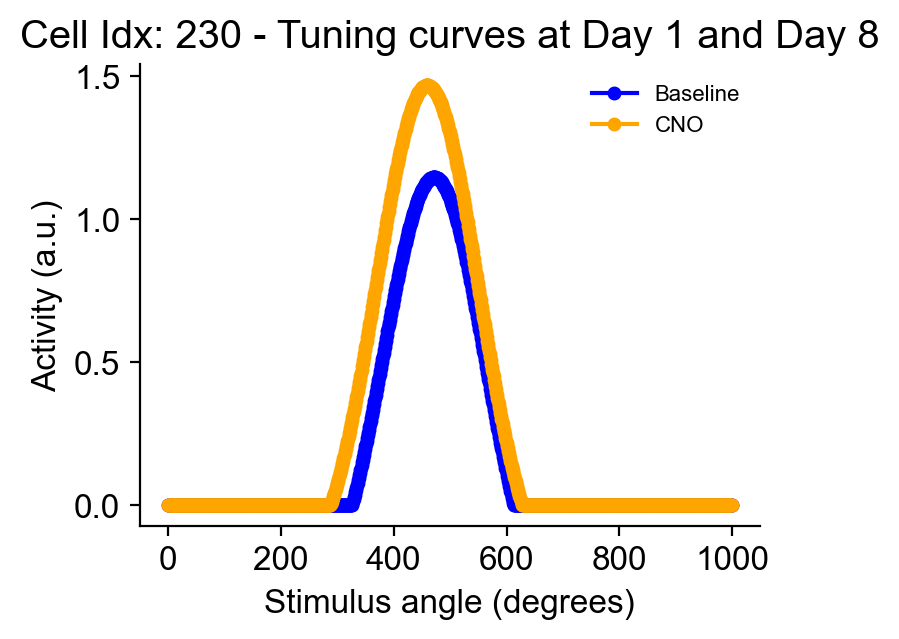

In [11]:
cell_idx = 230
plt.figure(figsize=(4, 3), dpi=200)
plt.plot(tuning_curves_day_1[cell_idx, :], c='blue', ls='-', marker='o', ms=4, label='Baseline')
plt.plot(tuning_curves_day_8[cell_idx, :], c='orange', ls='-', marker='o', ms=4, label='CNO')
plt.xlabel('Stimulus angle (degrees)')
plt.ylabel('Activity (a.u.)')
plt.legend(frameon=False, fontsize=8)
plt.title(f'Cell Idx: {cell_idx} - Tuning curves at Day 1 and Day 8')

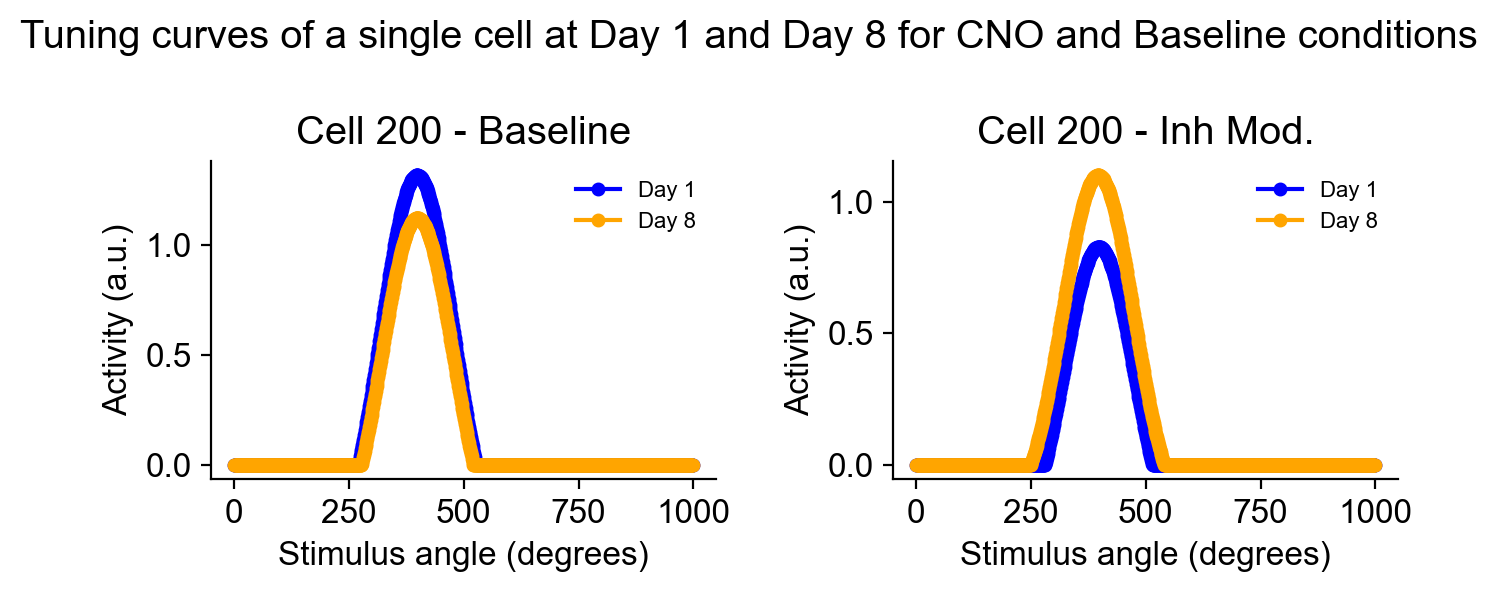

In [12]:
cell_idx = 200

fig, axs = plt.subplots(1, 2, figsize=(7, 3), dpi=200)


axs[0].plot(tuning_curves_day_1_non_varying[cell_idx, :], c='blue', ls='-', marker='o', ms=4, label='Day 1')
axs[0].plot(tuning_curves_day_8_non_varying[cell_idx, :], c='orange', ls='-', marker='o', ms=4, label='Day 8')
axs[0].set_xlabel('Stimulus angle (degrees)')
axs[0].set_ylabel('Activity (a.u.)')
axs[0].legend(frameon=False, fontsize=8)
axs[0].set_title(f'Cell {cell_idx} - Baseline')

axs[1].plot(tuning_curves_day_1[cell_idx, :], c='blue', ls='-', marker='o', ms=4, label='Day 1')
axs[1].plot(tuning_curves_day_8[cell_idx, :], c='orange', ls='-', marker='o', ms=4, label='Day 8')
axs[1].set_xlabel('Stimulus angle (degrees)')
axs[1].set_ylabel('Activity (a.u.)')
axs[1].legend(frameon=False, fontsize=8)
axs[1].set_title(f'Cell {cell_idx} - Inh Mod.')



fig.suptitle("Tuning curves of a single cell at Day 1 and Day 8 for CNO and Baseline conditions")
fig.tight_layout()

#### Plot tuning curves during CNO and at baseline


In [13]:
tuning_widths_day_1 = net.estimate_tuning_widths_at_day(day=1)
tuning_widths_day_8 = net.estimate_tuning_widths_at_day(day=8)

mean_day_1 = np.mean(tuning_widths_day_1)
mean_day_8 = np.mean(tuning_widths_day_8)

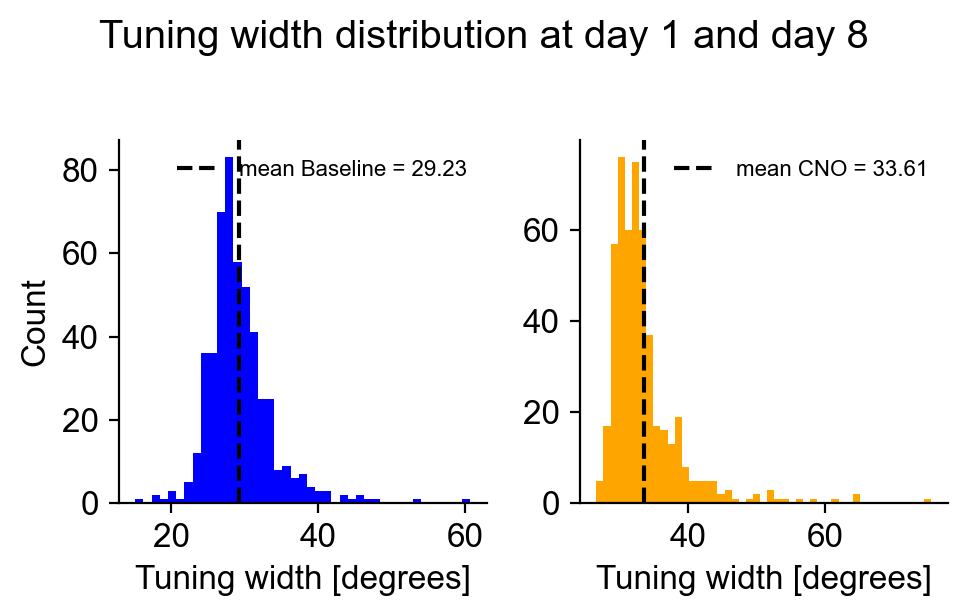

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(5, 3), dpi=200)

# plot histogram of tuning widths at day 0 and day 8
axs[0].hist(tuning_widths_day_1, bins='fd', color='blue')
axs[0].axvline(mean_day_1, c='black', ls='--', label=f'mean Baseline = {mean_day_1:.2f}')

axs[1].hist(tuning_widths_day_8, bins='fd', color='orange')
axs[1].axvline(mean_day_8, c='black', ls='--', label=f'mean CNO = {mean_day_8:.2f}')

axs[0].set_xlabel('Tuning width [degrees]')
axs[1].set_xlabel('Tuning width [degrees]')
axs[0].set_ylabel('Count')
axs[0].legend(frameon=False, fontsize=8)
axs[1].legend(frameon=False, fontsize=8)

fig.suptitle("Tuning width distribution at day 1 and day 8", y=1.02)
fig.tight_layout()


In [15]:
POs = np.array(net.POs)
POs.shape

POs_day_1 = POs[1, :]
POs_day_8 = POs[8, :]


In [16]:
POs.shape

(28, 500)

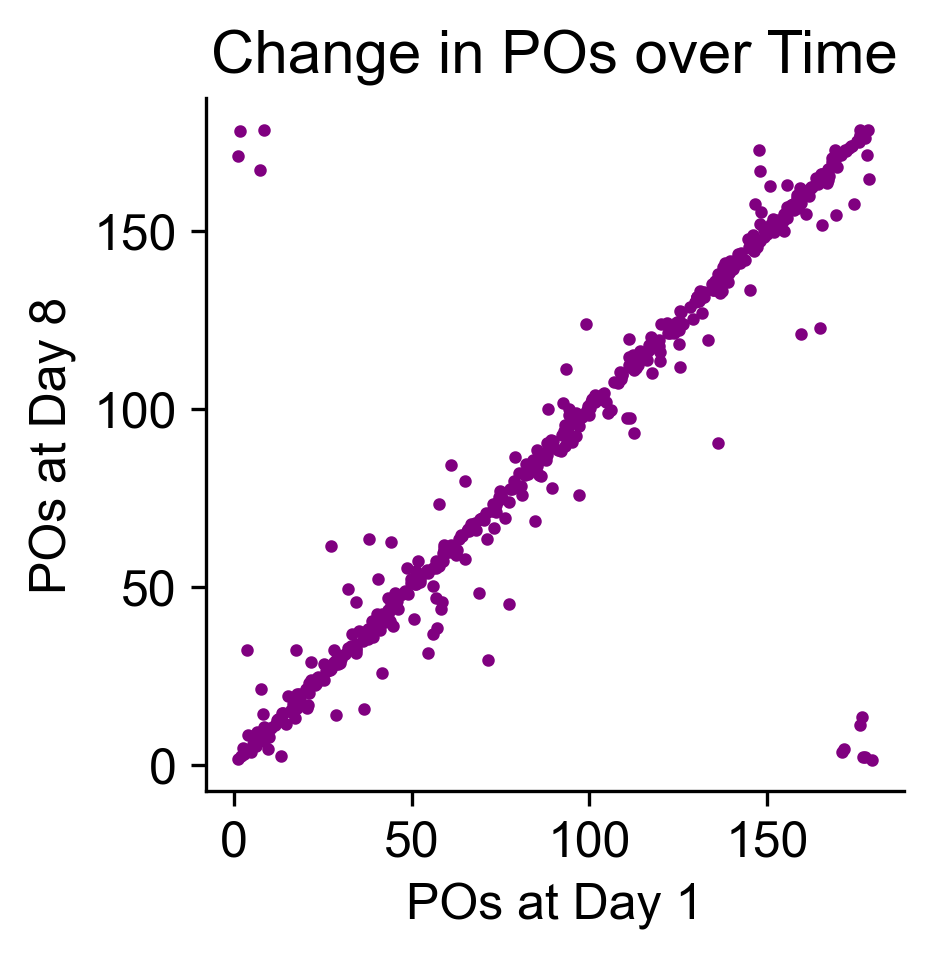

In [17]:
plt.figure(figsize=(3, 3), dpi=300)
plt.plot(POs_day_1, POs_day_8, c='purple', ls='', marker='o', ms=2)
plt.xlabel('POs at Day 1')
plt.ylabel('POs at Day 8')
plt.title('Change in POs over Time')
plt.show()

In [18]:
tuning_widths_day_1 = net.estimate_tuning_widths_at_day(day=1)
tuning_widths_day_2 = net.estimate_tuning_widths_at_day(day=2)

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/complete experiment - EI feedforward/../../src/network_time_varying.py:189: RuntimeWarning: invalid value encountered in divide
  curve /= np.max(curve)


Text(0.5, 1.0, 'Tuning widths at Day 1 vs Day 2')

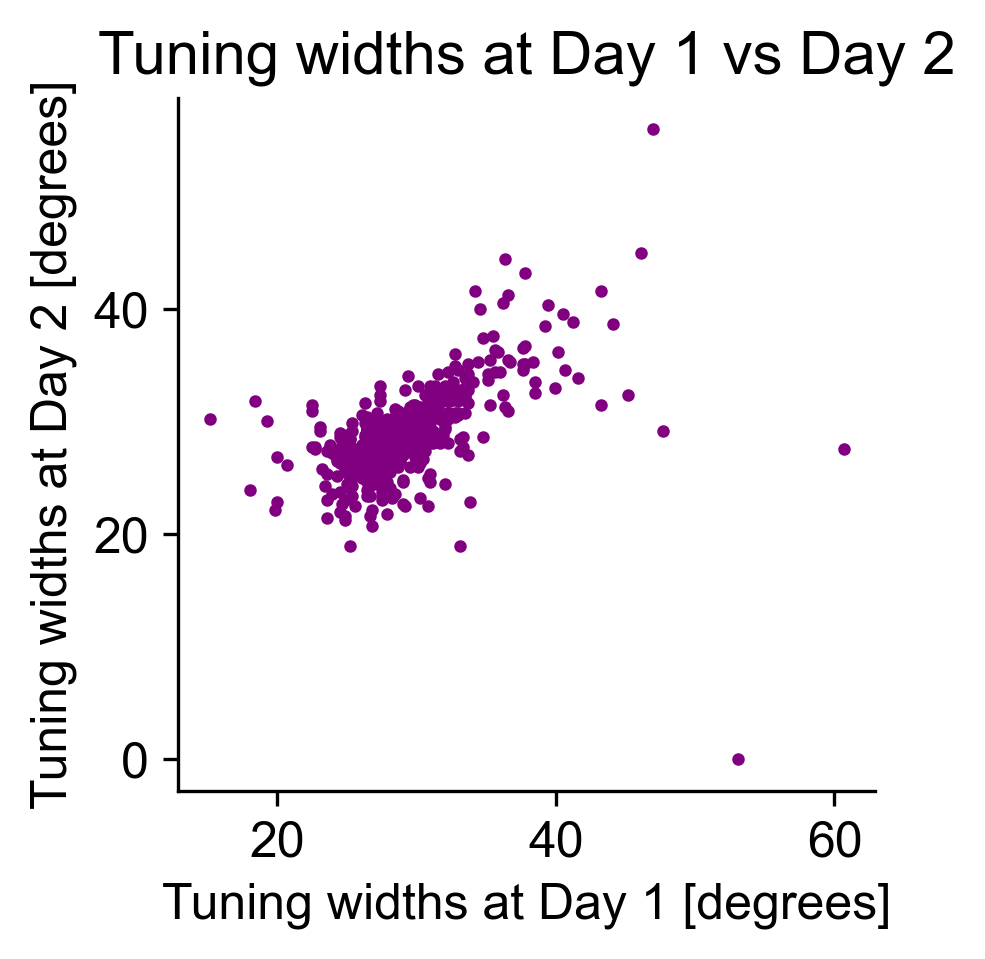

In [19]:
plt.figure(figsize=(3, 3), dpi=300)
plt.plot(tuning_widths_day_1, tuning_widths_day_2, c='purple', ls='', marker='o', ms=2)
plt.xlabel('Tuning widths at Day 1 [degrees]')
plt.ylabel('Tuning widths at Day 2 [degrees]')
plt.title('Tuning widths at Day 1 vs Day 2')

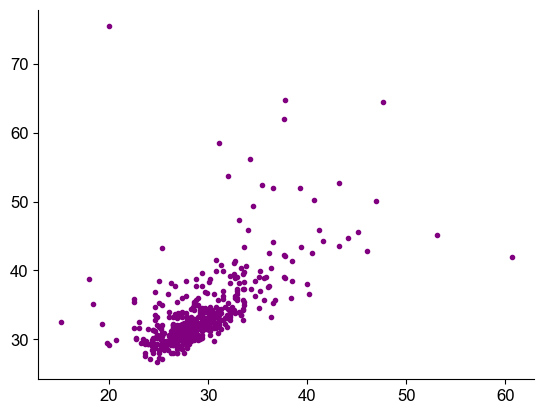

In [20]:
plt.figure(250)
plt.plot(tuning_widths_day_1, tuning_widths_day_8, c='purple', ls='', marker='o', ms=3)

Text(0.5, 1.0, 'Tuning width distribution at day 1 and day 8')

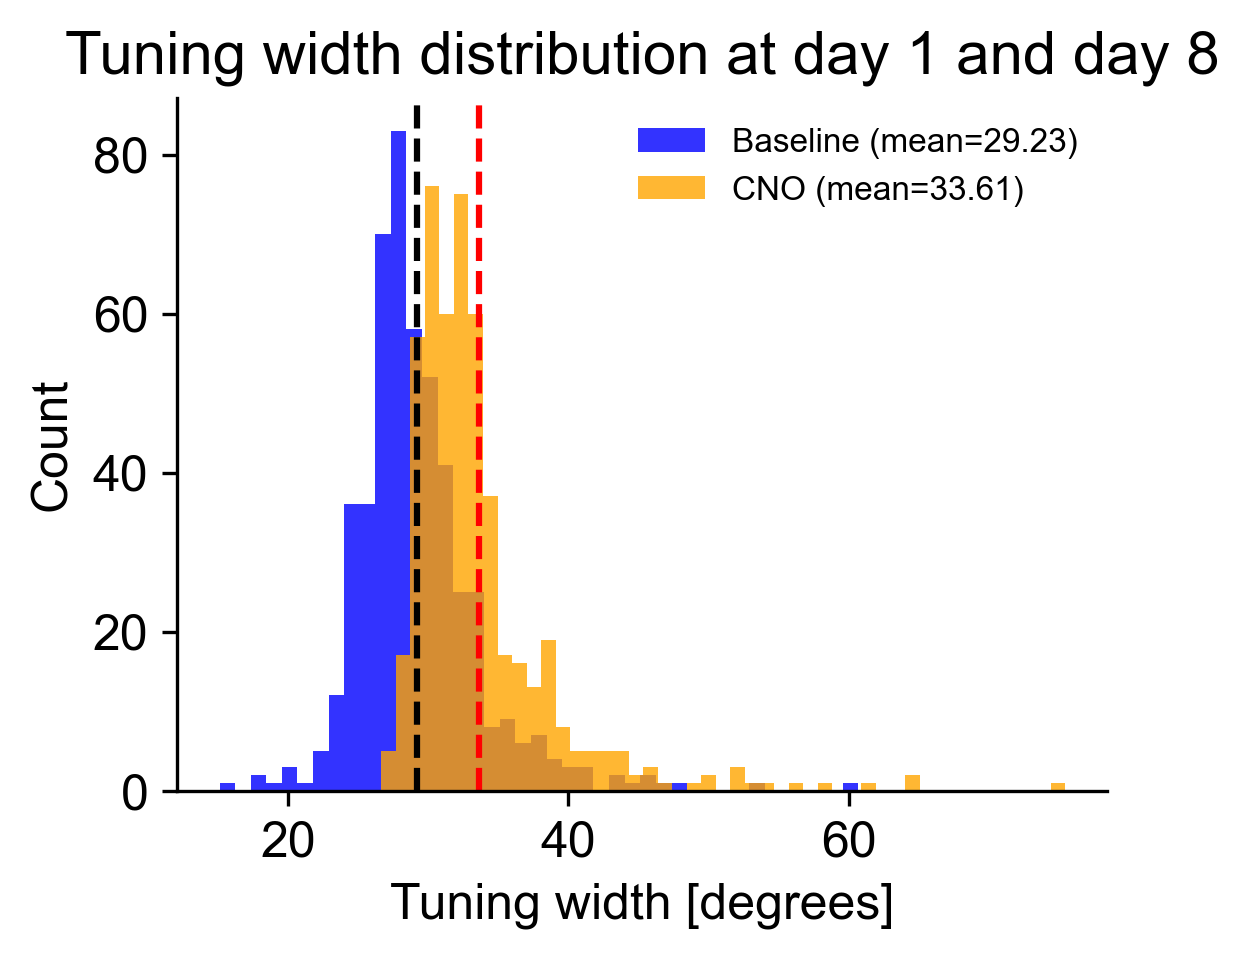

In [21]:
# combined plot

plt.figure(figsize=(4, 3), dpi=300)
plt.hist(tuning_widths_day_1, bins='fd', color='blue', alpha=0.8, label=f'Baseline (mean={mean_day_1:.2f})')
plt.axvline(mean_day_1, c='black', ls='--')
plt.hist(tuning_widths_day_8, bins='fd', color='orange', alpha=0.8, label=f'CNO (mean={mean_day_8:.2f})')
plt.axvline(mean_day_8, c='red', ls='--')
plt.xlabel('Tuning width [degrees]')
plt.ylabel('Count')
plt.legend(frameon=False, fontsize=8)
plt.title("Tuning width distribution at day 1 and day 8")

### Plot avg exc activity during CNO and baseline

In [22]:
avg_exc_activity_day_0 = net.estimate_avg_exc_activity_at_day(0)
avg_exc_activity_day_8 = net.estimate_avg_exc_activity_at_day(8)

mean_avg_exc_activity_day_0 = np.mean(avg_exc_activity_day_0)
mean_avg_exc_activity_day_8 = np.mean(avg_exc_activity_day_8)

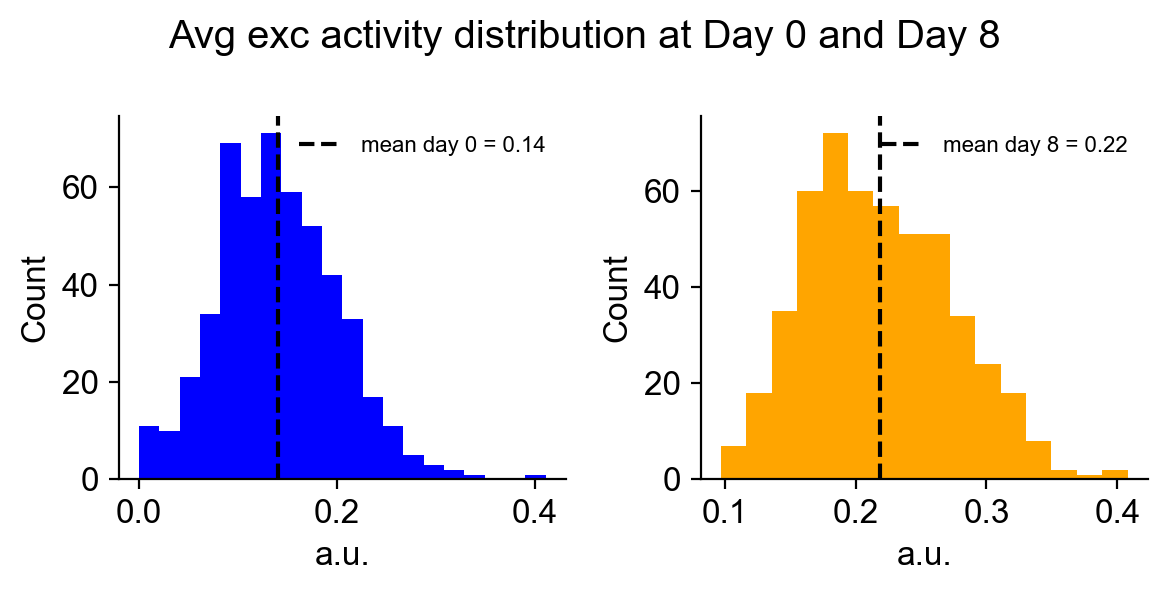

In [23]:
# histogram of avg exc activity at day 0 and day 8

fig, axs = plt.subplots(1, 2, figsize=(6, 3), dpi=200)

axs[0].hist(avg_exc_activity_day_0, bins='fd', color='blue')
axs[0].axvline(mean_avg_exc_activity_day_0, c='black', ls='--', label=f'mean day 0 = {mean_avg_exc_activity_day_0:.2f}')
axs[0].set_xlabel('a.u.')
axs[0].set_ylabel('Count')
axs[0].legend(frameon=False, fontsize=8)

axs[1].hist(avg_exc_activity_day_8, bins='fd', color='orange')
axs[1].axvline(mean_avg_exc_activity_day_8, c='black', ls='--', label=f'mean day 8 = {mean_avg_exc_activity_day_8:.2f}')
axs[1].set_xlabel('a.u.')
axs[1].set_ylabel('Count')

axs[1].legend(frameon=False, fontsize=8)

fig.suptitle("Avg exc activity distribution at Day 0 and Day 8")
fig.tight_layout()


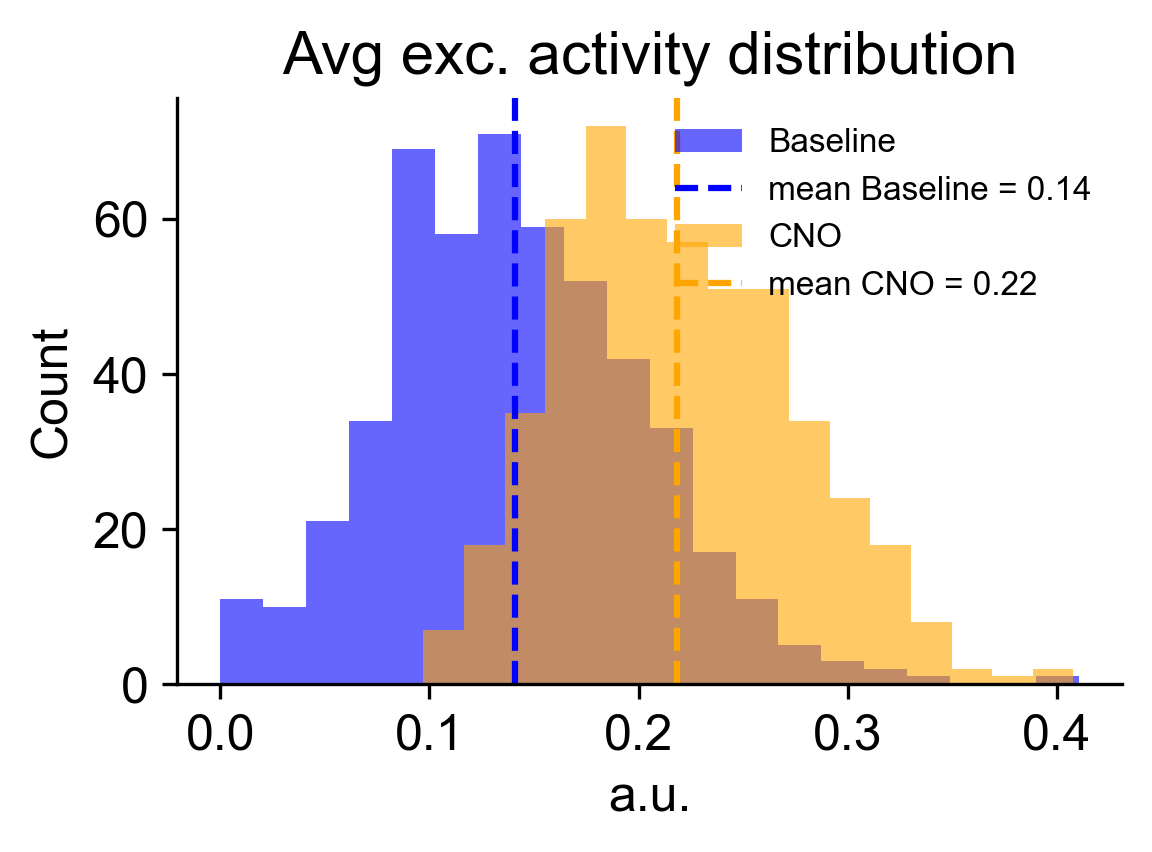

In [24]:
### combined plot
plt.figure(figsize=(4, 3), dpi=300)
plt.hist(avg_exc_activity_day_0, bins='fd', color='blue', alpha=0.6, label='Baseline')
plt.axvline(mean_avg_exc_activity_day_0, c='blue', ls='--', label=f'mean Baseline = {mean_avg_exc_activity_day_0:.2f}')
plt.hist(avg_exc_activity_day_8, bins='fd', color='orange', alpha=0.6, label='CNO')
plt.axvline(mean_avg_exc_activity_day_8, c='orange', ls='--', label=f'mean CNO = {mean_avg_exc_activity_day_8:.2f}')
plt.xlabel('a.u.')
plt.ylabel('Count')
plt.legend(frameon=False, fontsize=8)
plt.title('Avg exc. activity distribution')
plt.tight_layout()


### Plot avg inh activity during CNO and baseline

In [25]:
avg_inh_activity_day_1 = net.estimate_avg_inh_activity_at_day(1)
avg_inh_activity_day_8 = net.estimate_avg_inh_activity_at_day(8)

mean_inh_activity_day_1 = np.mean(avg_inh_activity_day_1)
mean_inh_activity_day_8 = np.mean(avg_inh_activity_day_8)


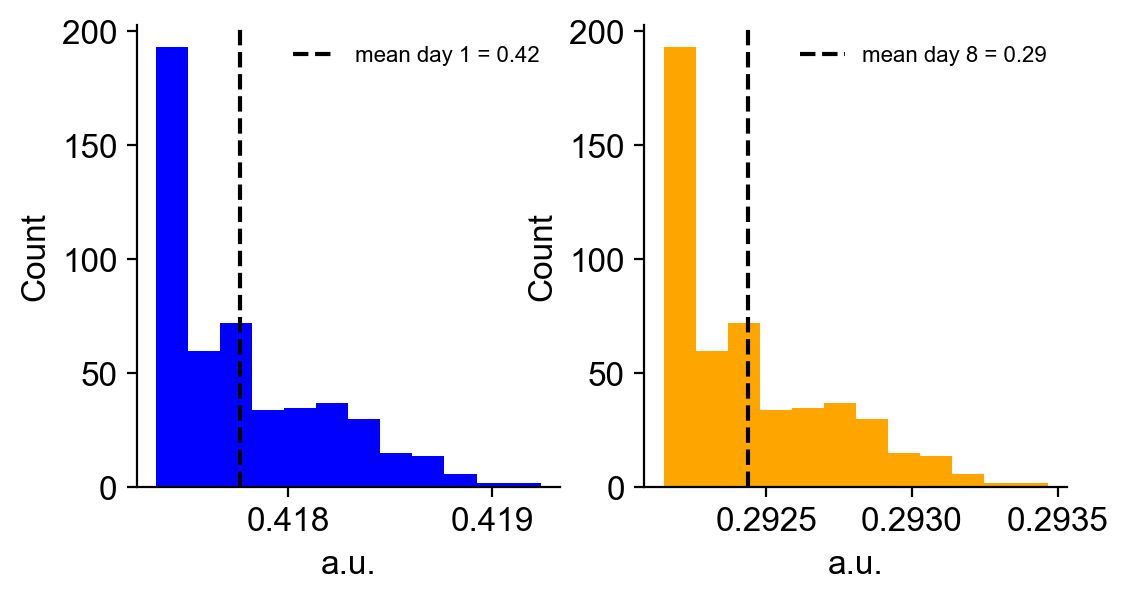

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), dpi=200)

axs[0].hist(avg_inh_activity_day_1, bins='fd', color='blue')
axs[0].axvline(mean_inh_activity_day_1, c='black', ls='--', label=f'mean day 1 = {mean_inh_activity_day_1:.2f}')
axs[0].set_xlabel('a.u.')
axs[0].set_ylabel('Count')
axs[0].legend(frameon=False, fontsize=8)

axs[1].hist(avg_inh_activity_day_8, bins='fd', color='orange')
axs[1].axvline(mean_inh_activity_day_8, c='black', ls='--', label=f'mean day 8 = {mean_inh_activity_day_8:.2f}')
axs[1].set_xlabel('a.u.')
axs[1].set_ylabel('Count')
axs[1].legend(frameon=False, fontsize=8)

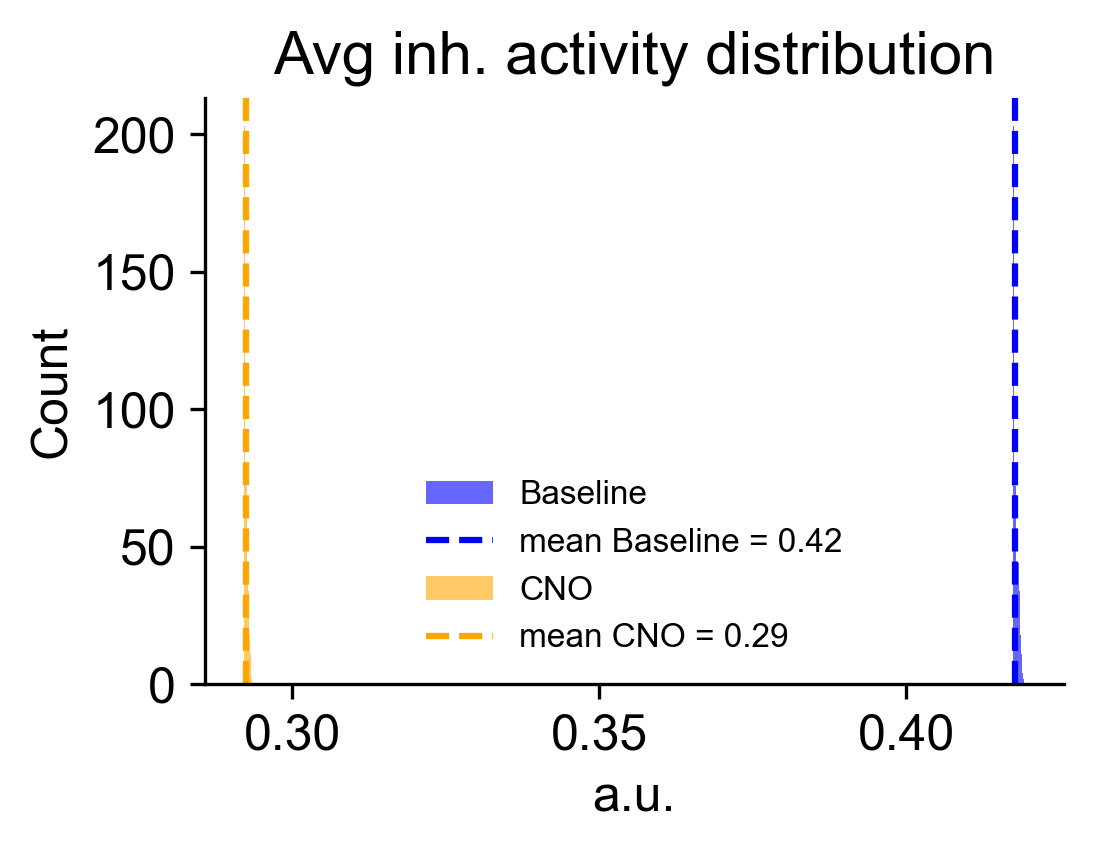

In [27]:
plt.figure(figsize=(4, 3), dpi=300)
plt.hist(avg_inh_activity_day_1, color='blue', alpha=0.6, label='Baseline')
plt.axvline(mean_inh_activity_day_1, c='blue', ls='--', label=f'mean Baseline = {mean_inh_activity_day_1:.2f}')
plt.hist(avg_inh_activity_day_8, color='orange', alpha=0.6, label='CNO')
plt.axvline(mean_inh_activity_day_8, c='orange', ls='--', label=f'mean CNO = {mean_inh_activity_day_8:.2f}')
plt.xlabel('a.u.')
plt.ylabel('Count')
plt.legend(frameon=False, fontsize=8)
plt.title('Avg inh. activity distribution')
plt.tight_layout()

### Pairwise correlations

In [28]:
pairwise_correlations_day_0 = net.estimate_pairwise_correlations_at_day(0)
pairwise_correlations_day_8 = net.estimate_pairwise_correlations_at_day(8)

mean_pairwise_corr_day_0 = np.mean(pairwise_correlations_day_0)
mean_pairwise_corr_day_8 = np.mean(pairwise_correlations_day_8)

print(f"Mean pairwise correlation at Day 0: {mean_pairwise_corr_day_0:.4f}" f"Mean pairwise correlation at Day 8: {mean_pairwise_corr_day_8:.4f}")

/Users/divyansh/miniforge3/envs/drift/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/divyansh/miniforge3/envs/drift/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Mean pairwise correlation at Day 0: nanMean pairwise correlation at Day 8: -0.0014


In [29]:
mean_pairwise_corrs = np.zeros(net.n_days)

for day in range(net.n_days):
    pairwise_corrs = net.estimate_pairwise_correlations_at_day(day)
    mean_pairwise_corrs[day] = np.mean(pairwise_corrs)


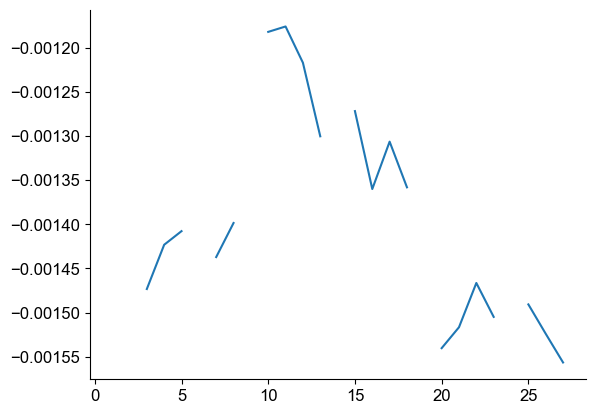

In [30]:
plt.plot(mean_pairwise_corrs)

### Population activity at Day 0 and Day 8

In [31]:
exc_pop_activity_day_1, inh_pop_activity_day_1 = net.estimate_pop_activity_at_day(1, 90)

exc_pop_activity_day_8, inh_pop_activity_day_8 = net.estimate_pop_activity_at_day(8, 90)

Text(0, 0.5, 'activity (a.u.)')

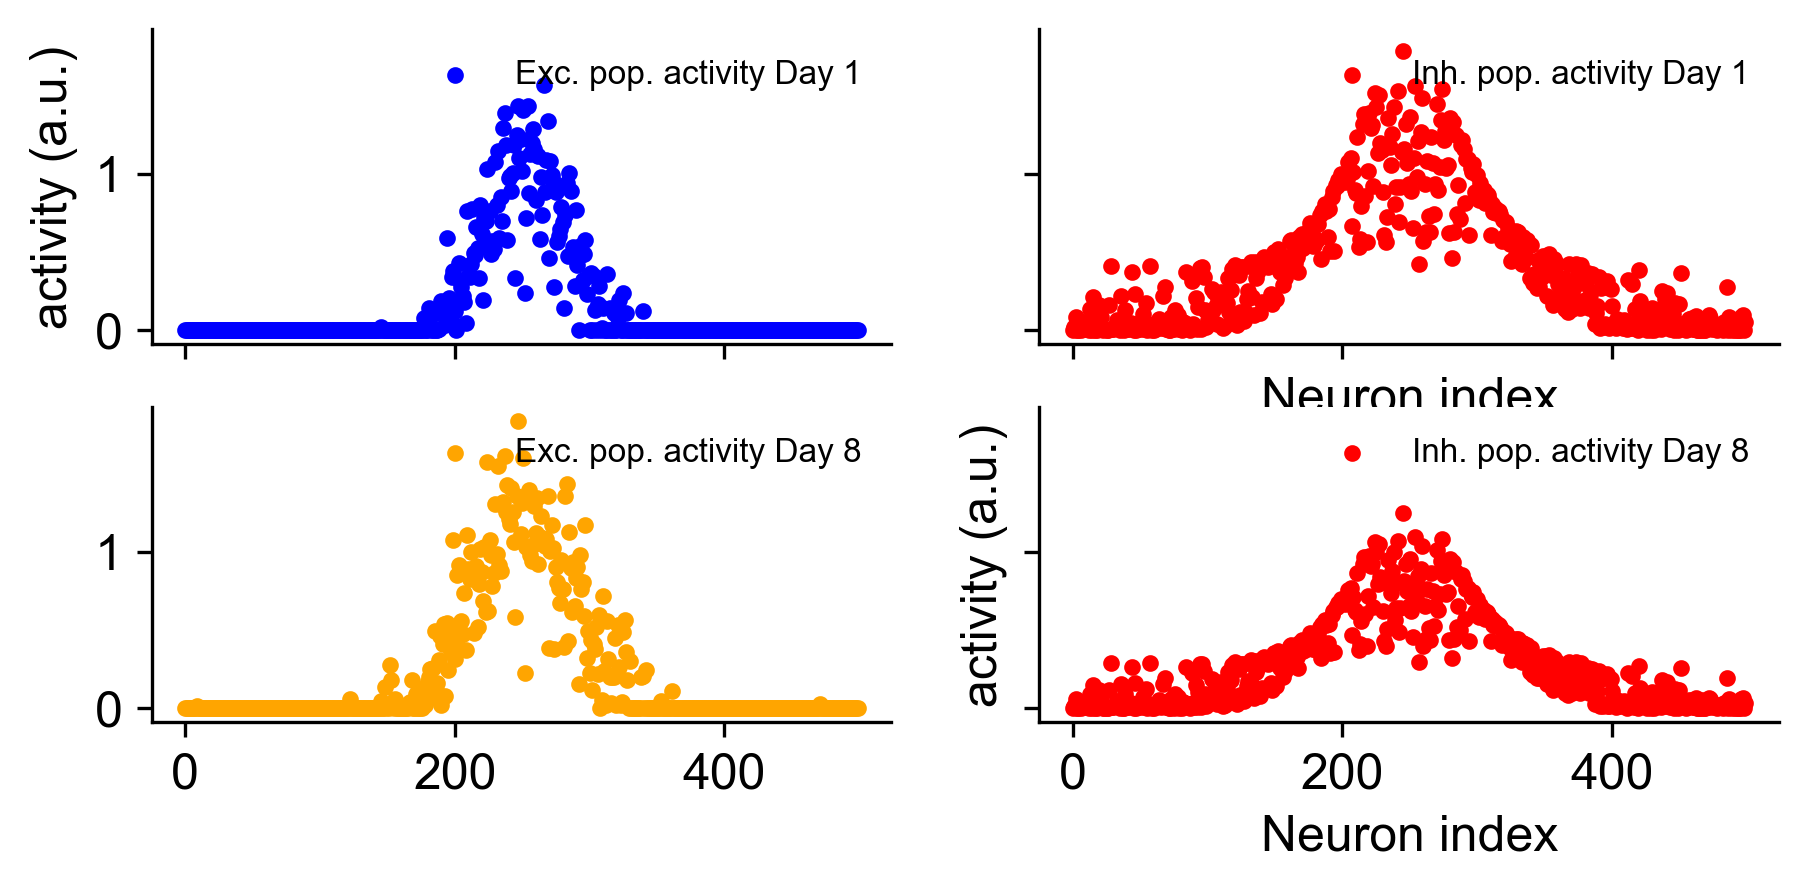

In [32]:
fig, axs = plt.subplots(2, 2, figsize=(7, 3), dpi=300, sharex=True, sharey=True)

nrn_idx_range = np.arange(net.N)
# make scatter of activity points at day 1 and day 8 for excitatory population
axs[0, 0].scatter(nrn_idx_range, exc_pop_activity_day_1, c='blue', marker='.', label='Exc. pop. activity Day 1')
axs[1, 0].scatter(nrn_idx_range, exc_pop_activity_day_8, c='orange', marker='.', label='Exc. pop. activity Day 8')

axs[0, 0].legend(frameon=False, fontsize=8)
axs[1, 0].legend(frameon=False, fontsize=8)
# axs[0, 0].set_xlabel('Neuron index')
axs[0, 0].set_ylabel('activity (a.u.)')

axs[0, 1].scatter(nrn_idx_range, inh_pop_activity_day_1, c='red', marker='.', label='Inh. pop. activity Day 1')
axs[1, 1].scatter(nrn_idx_range, inh_pop_activity_day_8, c='red', marker='.', label='Inh. pop. activity Day 8')

axs[0, 1].legend(frameon=False, fontsize=8)
axs[1, 1].legend(frameon=False, fontsize=8)


axs[0, 1].set_xlabel('Neuron index')


axs[1, 1].set_xlabel('Neuron index')
axs[1, 1].set_ylabel('activity (a.u.)')

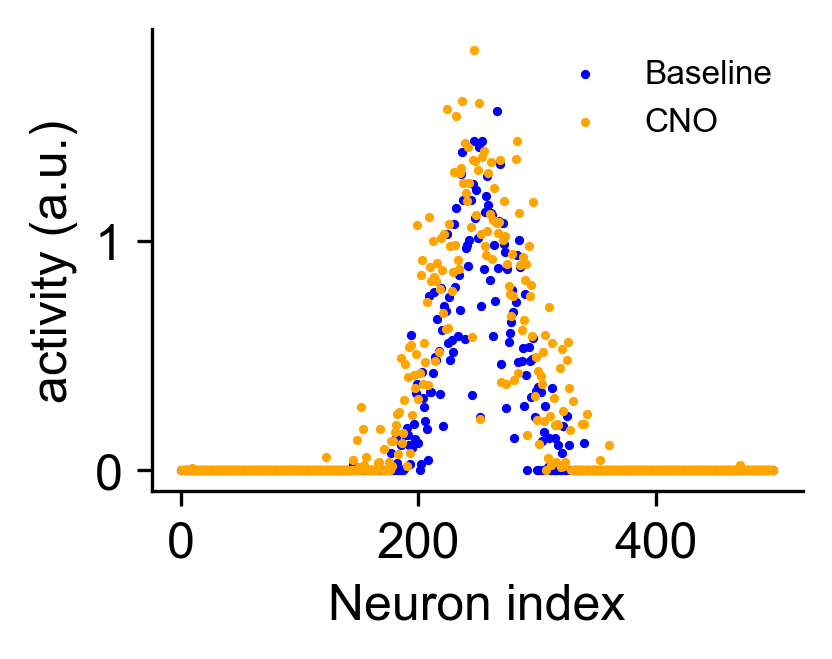

In [33]:
plt.rcParams['font.size'] = 12
plt.figure(figsize=(2.8,2), dpi=300)
plt.scatter(nrn_idx_range, exc_pop_activity_day_1, c='blue', marker='.', s=6, label='Baseline')
plt.scatter(nrn_idx_range, exc_pop_activity_day_8, c='orange', marker='.', s=6, label='CNO')
plt.xlabel('Neuron index')
plt.ylabel('activity (a.u.)')
plt.legend(frameon=False, fontsize=8)
# plt.title("Exc. pop activity")

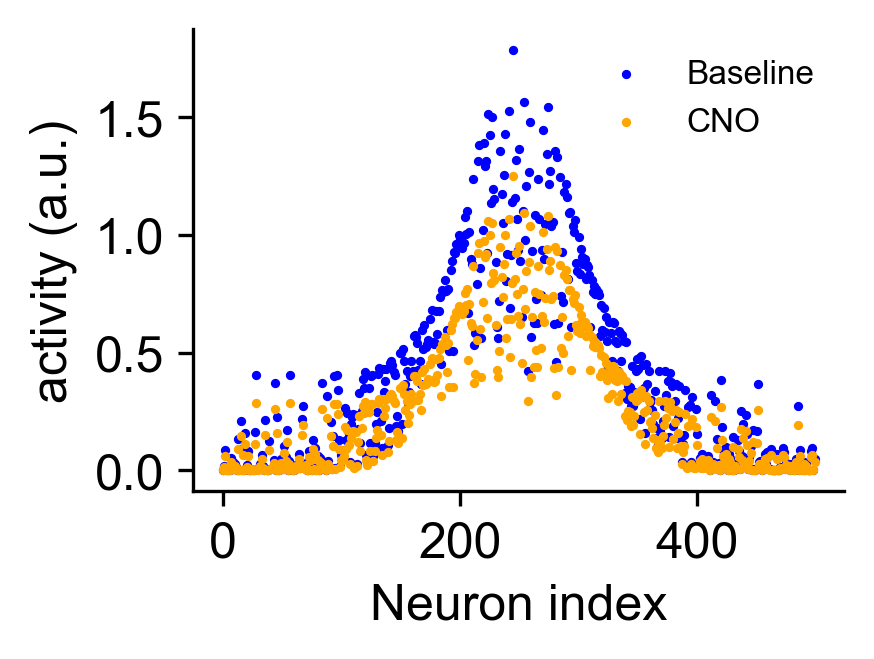

In [34]:
plt.rcParams['font.size'] = 12
plt.figure(figsize=(2.8,2), dpi=300)
plt.scatter(nrn_idx_range, inh_pop_activity_day_1, c='blue', marker='.', s=6, label='Baseline')
plt.scatter(nrn_idx_range, inh_pop_activity_day_8, c='orange', marker='.', s=6, label='CNO')
plt.xlabel('Neuron index')
plt.ylabel('activity (a.u.)')
plt.legend(frameon=False, fontsize=8)
# plt.title("Inh. pop activity")

### Visualization of population activity over time as an animation

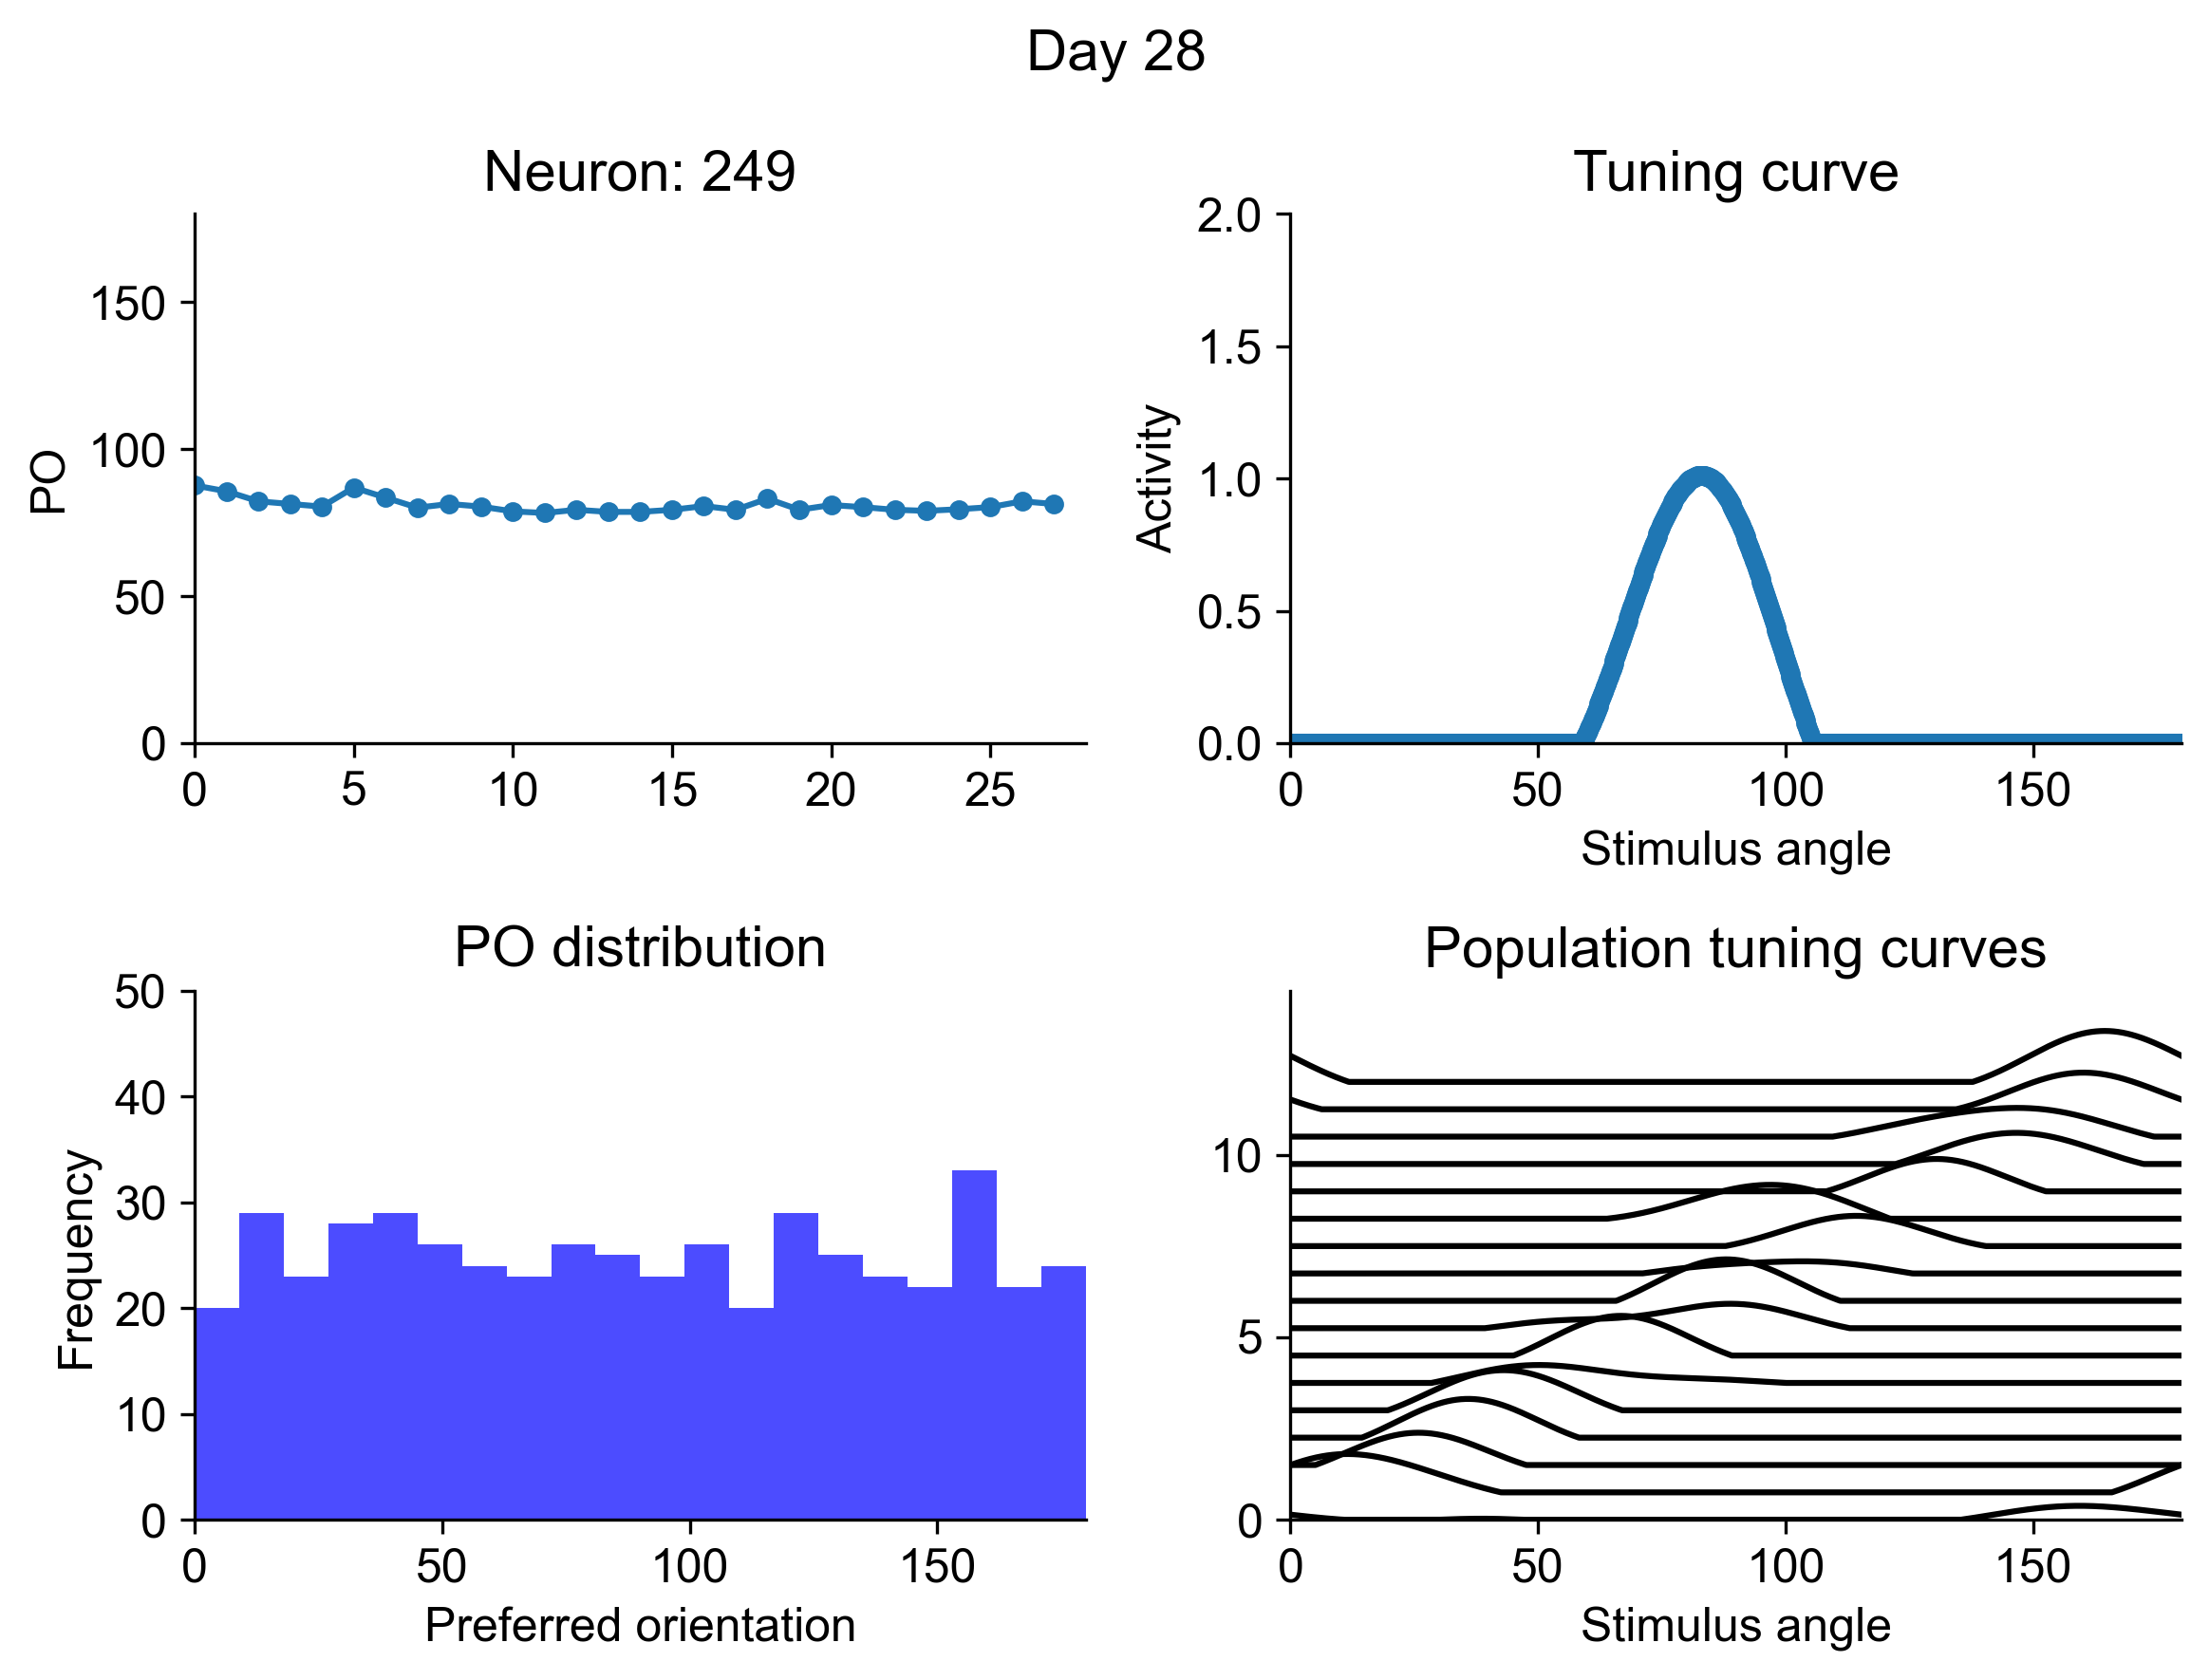

In [35]:

# create animation with three subplots

net.plot_animation_pop_activity()


### Plot drift magnitude vs initial cell tuning width

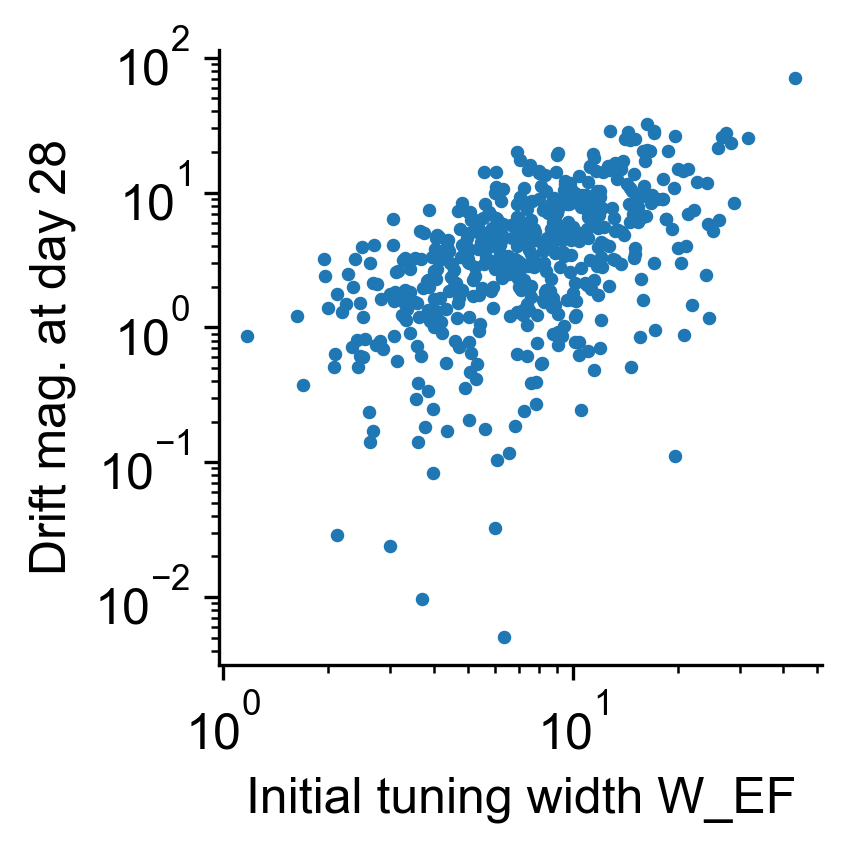

In [36]:
# initial_tuning_widths = net.estimate_tuning_widths_at_day(day=1)
initial_tuning_widths = net.vars_ef
plt.figure(figsize=(3, 3), dpi=300)
plt.scatter(initial_tuning_widths, drift_mag[-1], s=5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Initial tuning width W_EF")
plt.ylabel("Drift mag. at day 28")

plt.tight_layout()

Text(0.5, 1.0, 'Probe angle: 4')

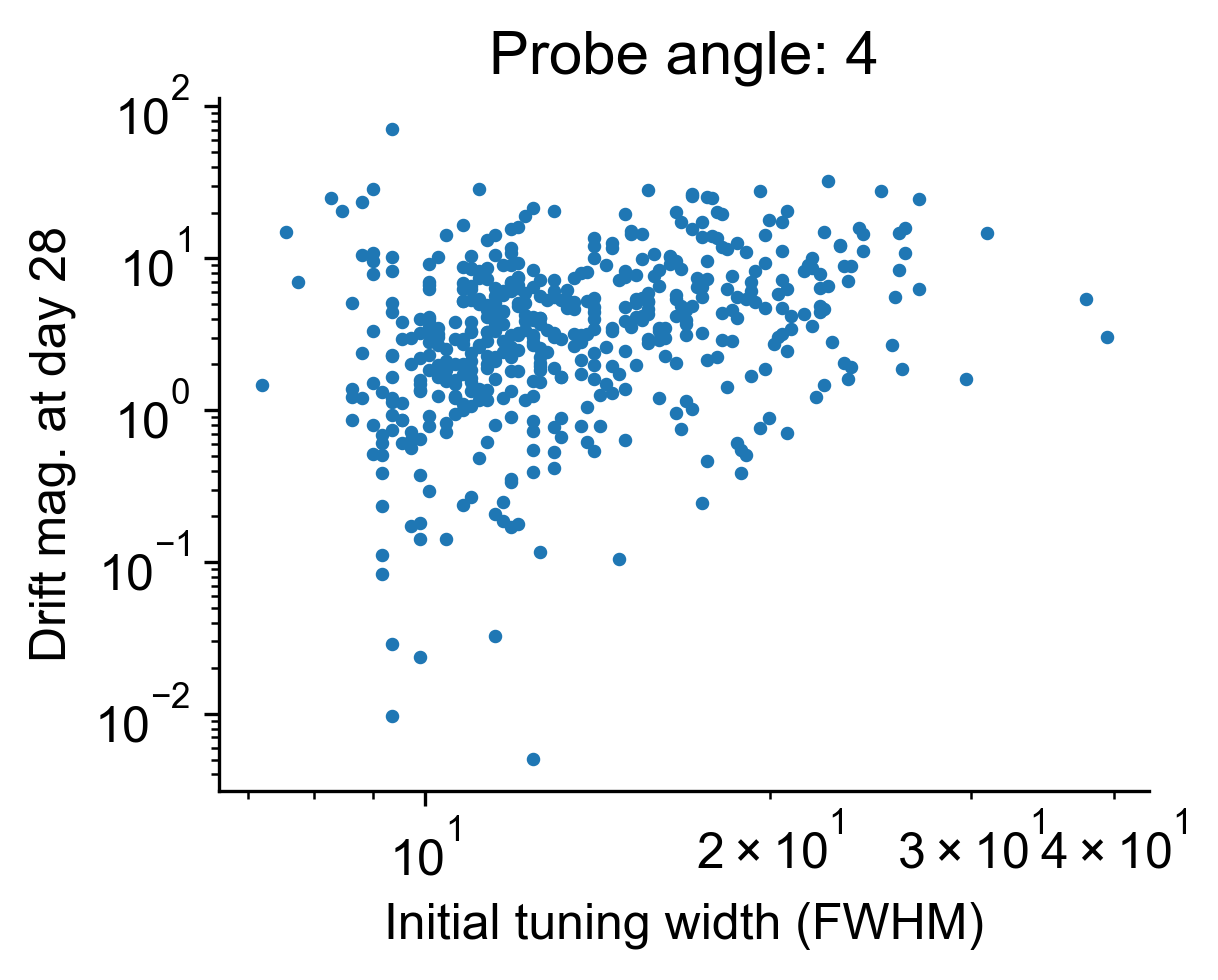

In [58]:
probe_angle = 4
initial_tuning_widths = net.estimate_tuning_widths_at_day(0, probe_sigma=probe_angle)

plt.figure(figsize=(4, 3), dpi=300)
plt.scatter(initial_tuning_widths, drift_mag[-1], s=5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Initial tuning width (FWHM)")
plt.ylabel("Drift mag. at day 28")
plt.title(f"Probe angle: {probe_angle}")

In [38]:
net.vars_ef

array([26.72990811, 12.63078202,  5.31593294, 11.30313978,  5.25700789,
       10.40055645,  8.77914888, 11.52318442,  4.73065107, 28.2439242 ,
        3.72302589,  8.01949498,  4.32377584, 11.05639814,  6.01704448,
        3.58368077,  5.99022046, 15.9613223 ,  1.94868201, 26.15096895,
       13.02466943, 12.71283236, 11.94460453,  3.42160264, 11.87382988,
       18.07818458,  4.19080432, 11.23950877,  8.87016063,  7.18406257,
        9.36236708, 11.76338225,  6.1474347 ,  2.99853824,  6.26907924,
       10.18799012, 15.87801353,  5.035108  ,  6.82040146,  8.88149838,
        3.41305371,  7.38110841, 10.14993989,  4.47144977,  2.34948839,
        6.00780717,  9.31653923, 17.03629483,  6.52932227,  7.2492772 ,
        7.48678753, 19.55450746,  7.61270975,  9.78249032,  9.44513711,
        5.53603209, 12.77836776,  6.17675814,  6.22485291,  5.06828746,
        9.67187773, 13.19733552, 12.30325756,  7.24712191,  3.27871943,
       14.87759017,  3.30537069, 14.52173668,  9.46167354,  3.32

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/complete experiment - EI feedforward/../../src/network_time_varying.py:189: RuntimeWarning: invalid value encountered in divide
  curve /= np.max(curve)


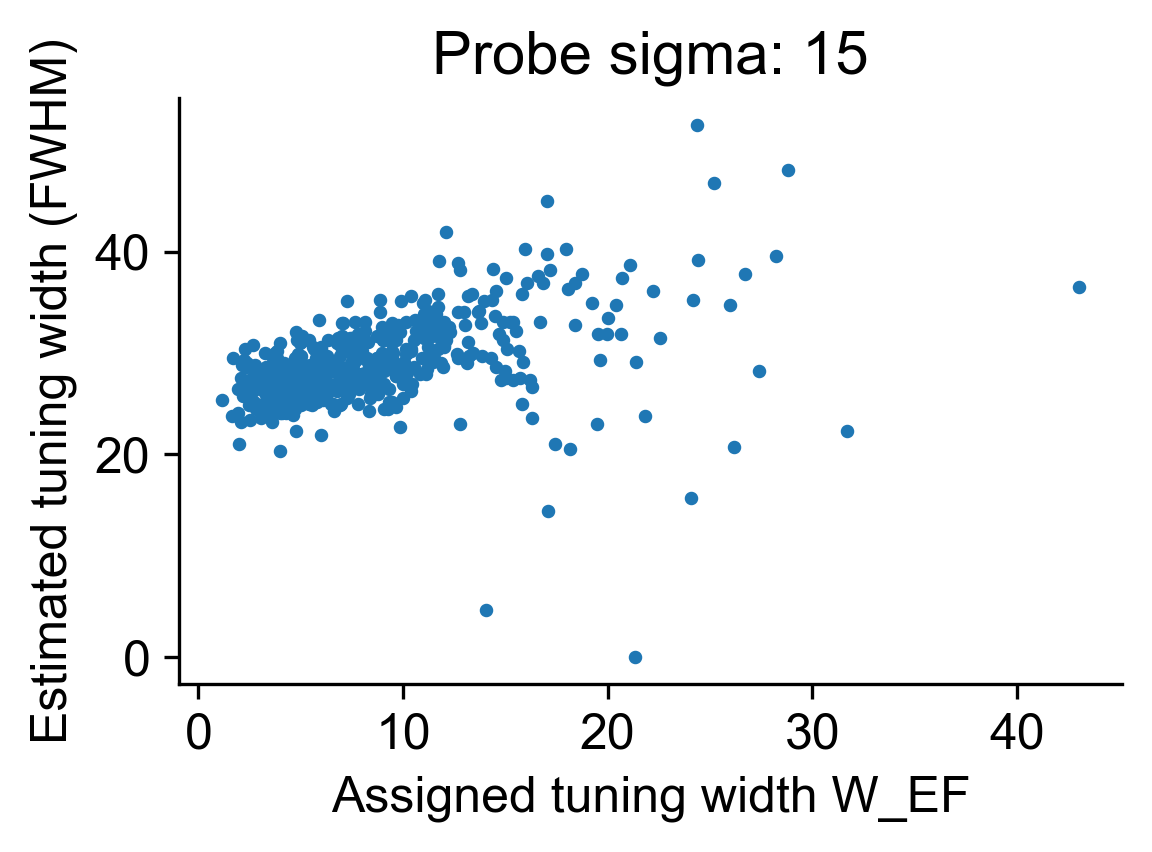

In [52]:
probe_angle = 15
inital_assigned_tuning_width = net.vars_ef
actual_initial_tuning_width = net.estimate_tuning_widths_at_day(0, probe_sigma=probe_angle)

plt.figure(figsize=(4, 3), dpi=300)
plt.scatter(inital_assigned_tuning_width, actual_initial_tuning_width, s=5)
# plt.xscale("log")
# plt.yscale("log") 
plt.xlabel("Assigned tuning width W_EF")
plt.ylabel("Estimated tuning width (FWHM)")
plt.title(f"Probe sigma: {probe_angle}")
plt.tight_layout()


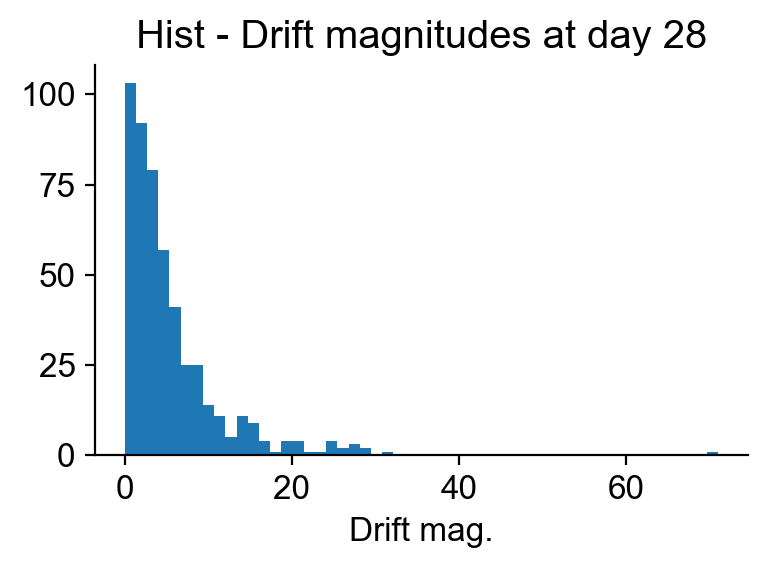

In [57]:
plt.figure(dpi=200, figsize=(4, 3))
plt.hist(drift_mag[-1], bins='fd')
plt.title("Hist - Drift magnitudes at day 28")
plt.xlabel("Drift mag.")
plt.tight_layout()

Text(0.5, 1.0, 'FWHM tuning (based on activity)')

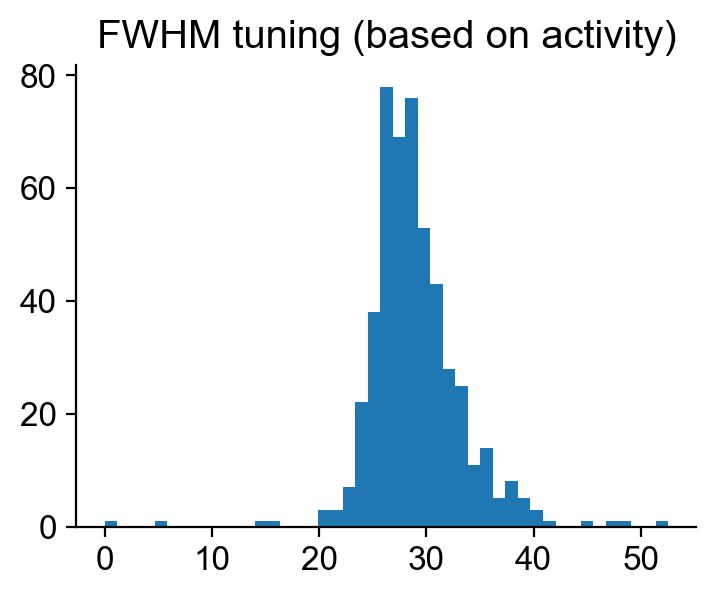

In [43]:
plt.figure(dpi=200, figsize=(4, 3))
plt.hist(actual_initial_tuning_width, bins='fd')

plt.title("FWHM tuning (based on activity)")


Text(0.5, 1.0, 'Assigned tuning width W_EF (log normal)')

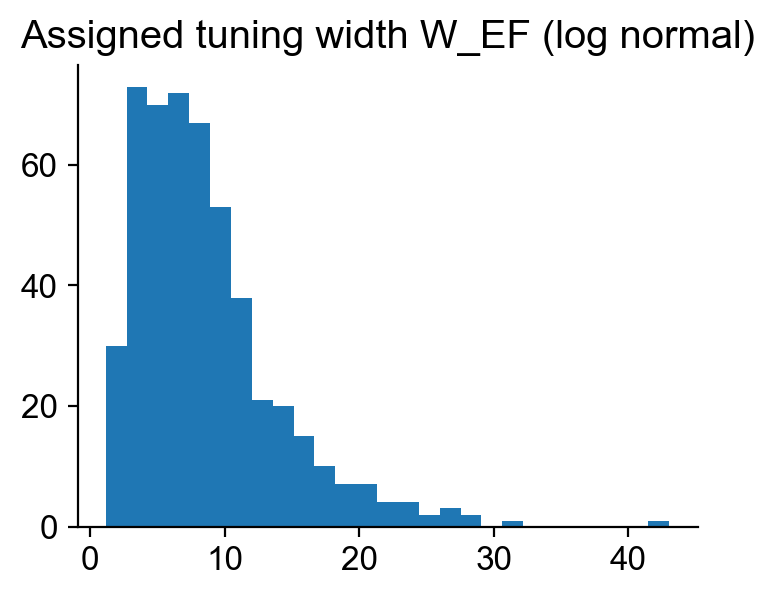

In [44]:
plt.figure(dpi=200, figsize=(4, 3))
plt.hist(inital_assigned_tuning_width, bins='fd')
plt.title("Assigned tuning width W_EF (log normal)")

Text(0, 0.5, 'Estimated tuning width at day 0 (FWHM)')

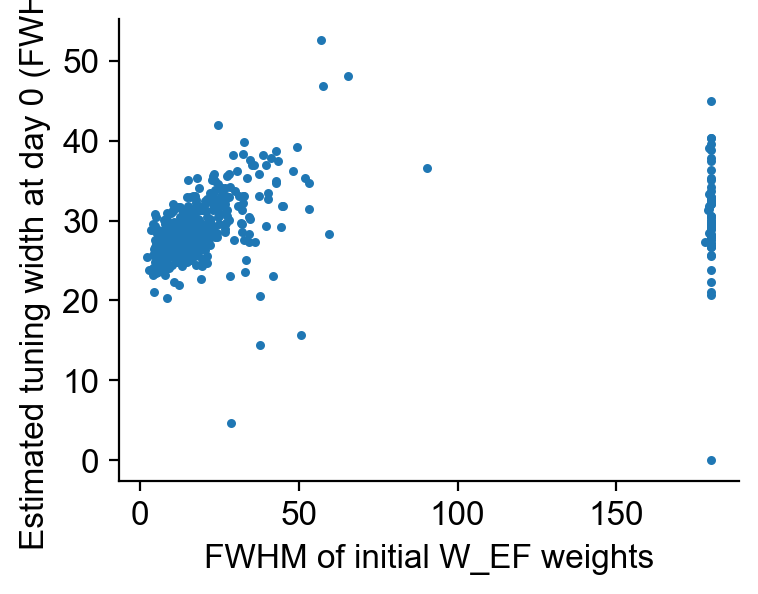

In [53]:
# Calculat FWHM of initial weights and compare with estimated tuning widths at day 0

init_weights = net.w_ef_init
x = np.linspace(0, 180, net.N, endpoint=False)
fwhm_init_weights = np.zeros(net.N)
for i in range(net.N):
    weight_profile = init_weights[:, i]
    weight_profile /= np.max(weight_profile) # normalize to max of 1
    half_max = 0.5
    indices_above_half_max = np.where(weight_profile >= half_max)[0]
    if len(indices_above_half_max) > 0:
        fwhm_init_weights[i] = x[indices_above_half_max[-1]] - x[indices_above_half_max[0]]
    else:
        fwhm_init_weights[i] = 0

plt.figure(dpi=200, figsize=(4, 3))
plt.scatter(fwhm_init_weights, actual_initial_tuning_width, s=5)
plt.xlabel("FWHM of initial W_EF weights")
plt.ylabel("Estimated tuning width at day 0 (FWHM)")